<a href="https://colab.research.google.com/github/helgadenes/Computational_Physics_USFQ/blob/main/Unit_4/4_9_Gaussian_smoothing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Gaussian smoothing:


We multiply the image in Fourier space times a Nd-Gaussian.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Gausssian mask:

$$f(x,y) = A \exp\left(-\left(\frac{(x - x_0)^2}{2\sigma_X^2} + \frac{(y - y_0)^2}{2\sigma_Y^2} \right)\right)$$

In [2]:
def mask_gaussian(x, y, sigma_x, sigma_y):
    """
    Function to get the 2D gaussian
    """

    return (1/(2*np.pi*sigma_x*sigma_y) *\
            np.exp(-(x**2/(2*sigma_x**2) \
                   + y**2/(2*sigma_y**2))))

### Grid:

In [3]:
# We select the sigmas
sigma_x = 0.5
sigma_y = 0.5

# We generate the vectors
x = np.linspace(-10, 10, 1600)  # Define x coordinates
y = np.linspace(-10, 10, 1600)  # Define y coordinates

# We create the meshgrid
X, Y = np.meshgrid(x, y)

# For the surface
Z = mask_gaussian(X, Y, sigma_x, sigma_y)



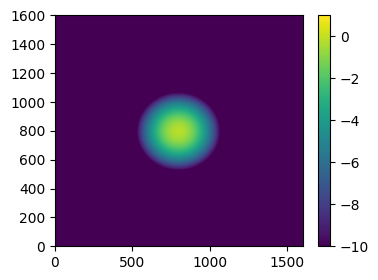

In [4]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(Z), shading='auto', cmap ="viridis", vmin = -10., vmax=1.)

plt.colorbar(Z1)

plt.show()

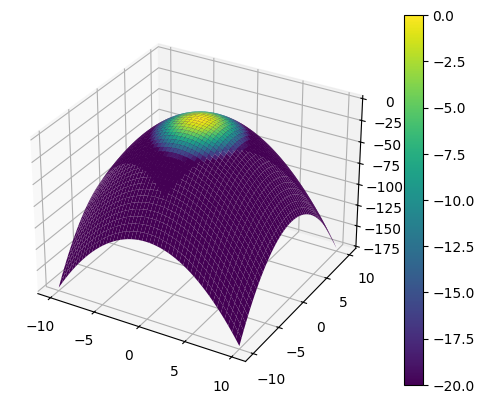

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, np.log10(Z), cmap ="viridis", clim= (-20, 0))
fig.colorbar(surf)

plt.show()

In [8]:
import matplotlib.image as mpimg

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
dir = "drive/MyDrive/Colab Notebooks/CP_1/Unit_4/"

Mounted at /content/drive


In [9]:
# Read image:

file = "Rubiks_cube.jpg"

img = mpimg.imread(dir+file)
print(img.shape)

# 2D image:

image_3 = img[:,:,0]
print(image_3.shape)

(1600, 1600, 3)
(1600, 1600)


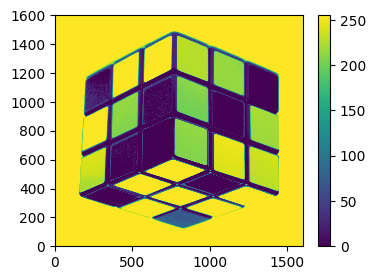

In [10]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(image_3, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

#plt.show()
plt.savefig("original.png")

### Fourier analysis:

In [11]:
# Signal
fourier_3 = np.fft.fft2(image_3)

shifted_fourier_3 = np.fft.fftshift(fourier_3)

# Gaussian kernel
mask_3 = np.fft.fft2(Z)

shifted_mask_3 = np.fft.fftshift(mask_3)

### Fourier transform of the image:

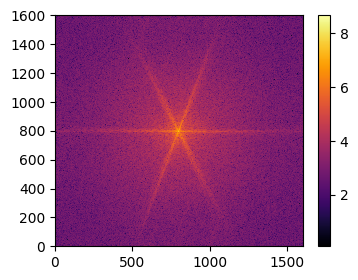

In [12]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(np.abs(shifted_fourier_3)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Fourier transform of the Gaussian mask:

/tmp/ipython-input-704405869.py:3: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(np.abs(shifted_mask_3)), shading='auto', cmap ="inferno")


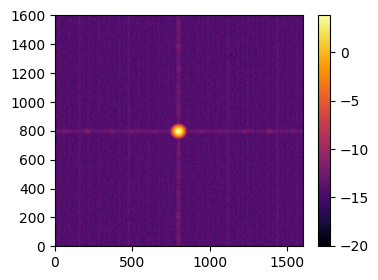

In [13]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(np.abs(shifted_mask_3)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Multiply the mask by the Fourier image:

In [14]:
masked_3 = shifted_fourier_3*shifted_mask_3

/tmp/ipython-input-2091601249.py:3: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(np.abs(masked_3)), shading='auto', cmap ="inferno")


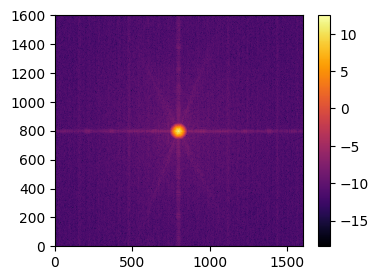

In [15]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(np.abs(masked_3)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Inverse Fourier transform:


In [16]:
inv_filter_3 = np.fft.ifftshift(masked_3)
inv_filter_3 = np.fft.ifft2(inv_filter_3)

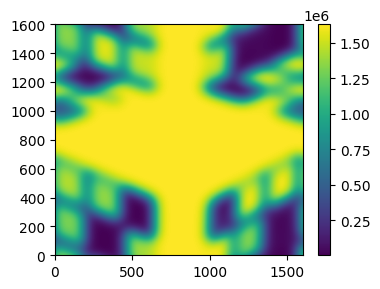

In [17]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(inv_filter_3.real, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()

### Rolling the image:

In [18]:
# Let's check how np.roll works

a = np.array([0,1,2,3,4,5,6,7,8,9])

print(a, a.shape)



[0 1 2 3 4 5 6 7 8 9] (10,)


In [19]:
b = np.roll(a, shift = 1)

print(b, b.shape)


[9 0 1 2 3 4 5 6 7 8] (10,)


In [20]:
b = np.roll(a, shift = 2)

print(b, b.shape)


[8 9 0 1 2 3 4 5 6 7] (10,)


In [21]:
c= np.roll(a, shift=a.shape[0]//2)

print(c)

[5 6 7 8 9 0 1 2 3 4]


In [22]:
inv_x = np.roll(inv_filter_3.real, inv_filter_3.shape[1]//2, axis = 1)
inv_xy = np.roll(inv_x, inv_filter_3.shape[0]//2, axis = 0)

### Rolled image:

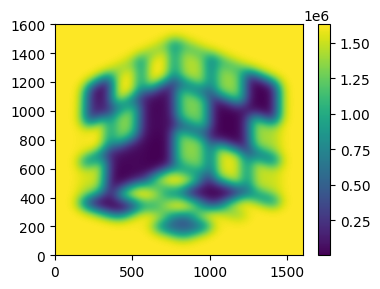

In [23]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(inv_xy, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

#plt.show()
plt.savefig("smoothed_05.png")

### Guassian smoothing with scipy


In [27]:
import scipy.ndimage as sn

In [28]:
# Original image -> image_3

smooth_im3 = sn.gaussian_filter(image_3, 20)

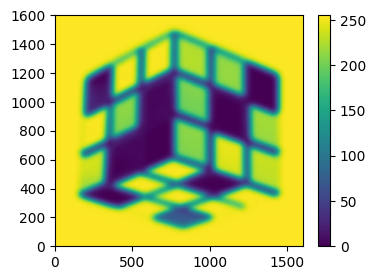

In [29]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(smooth_im3, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()
#plt.savefig("sigma8.png")